In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [4]:
df = pd.read_csv("data/hotel_bookings.csv")

# Ver las primeras filas
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
# Seleccionamos columnas útiles
features = [
    "lead_time",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "total_of_special_requests",
    "required_car_parking_spaces",
    "stays_in_weekend_nights",
    "stays_in_week_nights"
]

target = "is_canceled"

# Crear subconjunto de datos
data = df[features + [target]].dropna()


In [6]:
X = data[features]
y = data[target]


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [9]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [10]:
y_pred = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))


Accuracy: 0.7982243068933746

Matriz de confusión:
 [[13205  1828]
 [ 2990  5855]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.82      0.88      0.85     15033
           1       0.76      0.66      0.71      8845

    accuracy                           0.80     23878
   macro avg       0.79      0.77      0.78     23878
weighted avg       0.80      0.80      0.79     23878



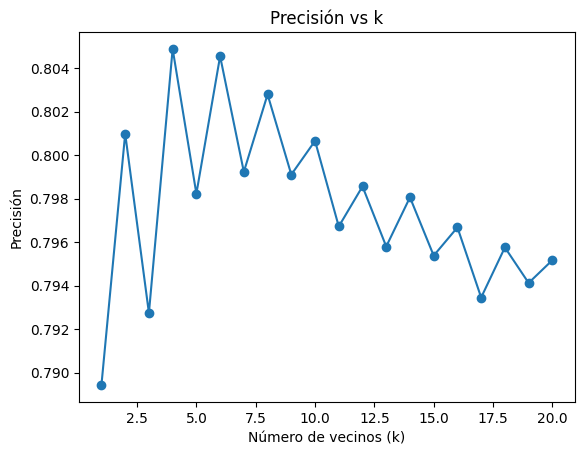

In [11]:
import matplotlib.pyplot as plt

acc = []
k_values = range(1, 21)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc.append(accuracy_score(y_test, y_pred))

plt.plot(k_values, acc, marker='o')
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Precisión")
plt.title("Precisión vs k")
plt.show()


In [86]:
# Crear un nuevo registro (en el mismo orden de tus features)
nuevo_registro = [[
    100,  # lead_time (días antes de la llegada)
    1,   # previous_cancellations
    1,   # previous_bookings_not_canceled
    0,   # booking_changes
    200,   # days_in_waiting_list
    2, # adr (precio promedio por noche)
    0,   # total_of_special_requests
    0,   # required_car_parking_spaces
    4,   # stays_in_weekend_nights
    10 # stays_in_week_nights
]]


In [87]:
# Escalar el nuevo registro usando el scaler entrenado
nuevo_registro_escalado = scaler.transform(nuevo_registro)


c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [88]:
# Predecir con el modelo KNN entrenado
prediccion = knn.predict(nuevo_registro_escalado)

# Mostrar resultado
if prediccion[0] == 1:
    print("🔴 El modelo predice que la reserva SERÁ CANCELADA.")
else:
    print("🟢 El modelo predice que la reserva NO SERÁ CANCELADA.")


🔴 El modelo predice que la reserva SERÁ CANCELADA.
